In [36]:
#Emotion-Detection using CV

In [37]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings("ignore")

In [38]:
fer="FER_2013"

In [39]:
for dirpath, dirnames, filenames in os.walk(fer):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in 'FER_2013'.
There are 7 directories and 0 images in 'FER_2013\test'.
There are 0 directories and 958 images in 'FER_2013\test\angry'.
There are 0 directories and 111 images in 'FER_2013\test\disgusted'.
There are 0 directories and 1024 images in 'FER_2013\test\fearful'.
There are 0 directories and 1774 images in 'FER_2013\test\happy'.
There are 0 directories and 1233 images in 'FER_2013\test\neutral'.
There are 0 directories and 1247 images in 'FER_2013\test\sad'.
There are 0 directories and 831 images in 'FER_2013\test\surprised'.
There are 7 directories and 0 images in 'FER_2013\train'.
There are 0 directories and 3995 images in 'FER_2013\train\angry'.
There are 0 directories and 436 images in 'FER_2013\train\disgusted'.
There are 0 directories and 4097 images in 'FER_2013\train\fearful'.
There are 0 directories and 7215 images in 'FER_2013\train\happy'.
There are 0 directories and 4965 images in 'FER_2013\train\neutral'.
There are 0 directorie

In [40]:
train_dir='FER_2013/train/'
test_dir='FER_2013/test/'

In [41]:
data_dir = os.path.abspath(train_dir)
class_names = np.array(sorted([item for item in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, item))]))
print(class_names)

['angry' 'disgusted' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [42]:
def fer_img(dir, cls):
    folder = os.path.join(dir, cls)
    img_name = random.choice(os.listdir(folder))
    img_path = os.path.join(folder, img_name)
    
    img = Image.open(img_path)
    plt.imshow(img,cmap='grey')
    plt.title(cls)
    plt.axis('off')
    plt.show()
    
    print(f'Image size: {img.size}')
    return img

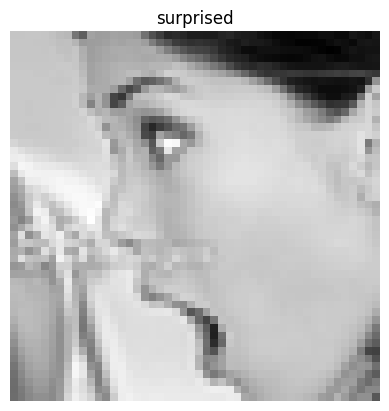

Image size: (48, 48)


In [43]:
img=fer_img(dir=train_dir, cls=random.choice(class_names))

In [44]:
IMG_SZ = (48, 48)
BS = 32

datagen = ImageDataGenerator(
    rotation_range=20,
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [45]:
train_data = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SZ,
    color_mode='rgb',
    class_mode='binary',
    batch_size=BS,
    shuffle=True,
    subset='training',
    seed=512
)

val_data = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SZ,
    color_mode='rgb',
    class_mode='binary',
    batch_size=BS,
    shuffle=True,
    subset='validation',
    seed=512
)

test_data = datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SZ,
    color_mode='rgb',
    class_mode='binary',
    batch_size=BS
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [46]:
#VGG16 Fine-Tuning

In [48]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dropout, GlobalAveragePooling2D, Dense

In [49]:
vgg = VGG16(weights="imagenet", include_top=False, input_shape=(48, 48, 3))
vgg.trainable = True
vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 48, 48, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 48, 48, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 48, 48, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 24, 24, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 3, 3, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 3, 3, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 3, 3, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 3, 3, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 1, 1, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
model = tf.keras.Sequential([
    vgg,
    GlobalAveragePooling2D(),
    Dense(7, activation='softmax')
])

In [51]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(3e-4),
              metrics=['accuracy'])

In [52]:
history = model.fit(train_data,
                    epochs=20,
                    steps_per_epoch=len(train_data),
                    validation_data=val_data,
                    validation_steps=len(val_data))

Epoch 1/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 933s 1s/step - accuracy: 0.2437 - loss: 1.8367 - val_accuracy: 0.3005 - val_loss: 1.7031
Epoch 2/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 152us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 3/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 921s 1s/step - accuracy: 0.3065 - loss: 1.6858 - val_accuracy: 0.3952 - val_loss: 1.5508
Epoch 4/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 47us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 5/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 918s 1s/step - accuracy: 0.4290 - loss: 1.4652 - val_accuracy: 0.4686 - val_loss: 1.3890
Epoch 6/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 45us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 7/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 921s 1s/step - accuracy: 0.4840 - loss: 1.3315 - val_accuracy: 0.5145 - val_loss: 1.2690
Epoch 8/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 61us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 9/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 763s 1s/step - accuracy: 0.5260 - loss: 1.2511 - val_accuracy: 

In [56]:
model.evaluate(test_data)

225/225 ━━━━━━━━━━━━━━━━━━━━ 142s 629ms/step - accuracy: 0.5870 - loss: 1.1154


[1.1109569072723389, 0.584703266620636]

In [66]:
pth='fermodel.keras'
model.save(pth)